<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Estimating Snow-Water-Equivalent (SWE) from Scanning Radar with a Random Forest

:::{important} Goal
The goal of this notebook is to showcase a **gentle, end-to-end introduction to Random Forest regression** built around a real
atmospheric-science problem: turning scanning-radar measurements into estimates of how much liquid water
has accumulated as snow over a 20-minute window during the Atmospheric Radiation Measurement Facility's
Surface Atmosphere Integrated Laboratory (SAIL) deployment at Crested Butte, CO. 
:::

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/ai-ml/random-forest-sail-swe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<cr><img src='../../images/figures/sail.jpg' width=800></cr>

## Overview
During [SAIL](https://arm.gov/research/campaigns/amf2021sail), the X-band Precipitation Radar from Colorado State University did full volume scans over the Upper Colorado River Basin from October 2021 - June 2023. From these scans, the ARM Facility developed a [Value Added Product](https://armgov.svcs.arm.gov/data/science-data-products/vaps) called [Extracted Radar Columns and In-Situ Sensors (RadClss)](https://armgov.svcs.arm.gov/data/science-data-products/vaps/radclss), which provided vertical columns of radar moments over all SAIL deployment sites (@obrien_radclss_2024). The data from RadCLss are used to train the models in this notebook (@obrien_sail_radclss).

The ARM Facility also developed [Surface Quantitative Precipitation Estimates (SQUIRE)](https://armgov.svcs.arm.gov/data/science-data-products/vaps/squire), a snow water equivalent best estimate product produced from the X-band Precipitaiton Radar scans (@grover_2023_squire). @Jackson_2026_SQUIRE evaluated different empirical estimators, power law relationships between $Z_{e}$ and $S$, or $Z_{e}+K_{dp}$ and $S$, or $S$ and $K_{dp}$, against ground based weighing bucket rain gauges (Pluvio) and melted snow equivalent measurements. From these comparisons, they concluded that $Z_{e}-S$ relationships typically provided the best estimates of SWE and therefore were used in SQUIRE. 

where:
- $Z_{e}$ is the radar equivalent reflectivity factor
- $K_{dp}$ is radar specific differential phase
- $S$ is estimated snowfall rate
- $SWE$ is snow water equivalent

**Here, we will repeat a similar analysis, but using Random Forest and MLP machine learning techniques in place of power law functions.**


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Scikit-learn](https://scikit-learn.org/stable/) | Helpful | Machine learning library for clustering and preprocessing |
| [PyTorch Tutorials](https://docs.pytorch.org/tutorials/) | Necessary | Machine learning library for building and training deep learning models|

- **Time to learn**: 60 min.
- **System requirements**: pytorch dependency

## Outline
### What you'll learn
1. **The data** — what the radar features (`Ze`, `Kdp`) are, and what we are trying to predict (`SWE`).
2. **A clean train / validation / test split** — and why we split *by day* rather than randomly.
3. **Random Forest 101** — what a Random Forest is, why it works well on tabular data, and what each hyperparameter actually does.
4. **Evaluation** — how to read Mean Absolute Error (MAE) and Squared Correlation Coefficient (R²), and how to compare a learned model against a physical baseline (`Ze = 40 · S²`).
5. **A short Neural Network comparison** — using the same features so you can see how Random Forest stacks up against a small MLP.

### How to use this notebook
- Run the cells **top-to-bottom**.
- Markdown cells explain the *why*; code cells do the *what*.
- Make sure the data files (`radar_swe_20min_all_cases.npz` and `radar_swe_20min_index.csv`) path is correct to your stored data location.

---

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to also upload the data files (`radar_swe_20min_all_cases.npz` and `radar_swe_20min_index.csv`) after opening this notebook
:::

In [1]:
# Silence noisy deprecation / convergence warnings so the notebook is easier to read.
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --- core data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- scikit-learn: models ---
from sklearn.ensemble import RandomForestRegressor   # the star of this notebook
from sklearn.neural_network import MLPRegressor      # small comparison neural net
from sklearn.pipeline import Pipeline                # chains preprocessing + model
from sklearn.preprocessing import StandardScaler     # zero-mean / unit-variance for the NN

# --- scikit-learn: evaluation ---
from sklearn.metrics import mean_absolute_error, r2_score

## 1. The dataset

We pre-built a multi-case machine-learning dataset of **20-minute accumulated snow-water-equivalent (SWE)** from
ARM RadCLss radar column NetCDF files (@obrien_sail_radclss). Three quantities matter here:

| Variable | Symbol | Units | Role |
|---|---|---|---|
| Corrected radar reflectivity | `Ze` | dBZ | **Input feature** — how strongly the snow scatters the radar beam at each height |
| Filtered specific differential phase | `Kdp` | deg/km | **Input feature** — sensitive to ice/snow shape and orientation |
| 20-minute accumulated SWE | `y_swe` | mm | **Target** — what we want to predict |

Each sample is a **vertical profile** through the storm:

- Heights are restricted to **3300–5300 m** (where the snow-relevant signal lives), giving **41 vertical bins**.
- For each profile we compute window-mean values aligned with the 20-minute SWE accumulation target.
- Everything is bundled into `radar_swe_20min_all_cases.npz` (arrays) and `radar_swe_20min_index.csv` (case index).

So each training example has **41 Ze values + 41 Kdp values = 82 features**, and one scalar SWE **target**.

In [3]:
# Where the pre-processed data lives.
# By default, we look within the repo's data folder/directory.
# If you've stored the files elsewhere, point save_dir at that directory, e.g. Path('/data/swe').
save_dir = Path("../data")
npz_path = save_dir / 'radar_swe_20min_all_cases.npz'
csv_path = save_dir / 'radar_swe_20min_index.csv'

In [4]:
# Load the bundled dataset. The .npz is a dict-like archive of NumPy arrays.
d = np.load(npz_path, allow_pickle=True)

X_ze        = d['X_ze']                    # (n_samples, 41) Ze profile, dBZ
X_kdp       = d['X_kdp']                   # (n_samples, 41) Kdp profile, deg/km
y_swe       = d['y_swe'].astype(float)     # (n_samples,)    20-min accumulated SWE, mm  -> target
height_ze   = d['height_ze']               # (41,) heights of the Ze bins, m
height_kdp  = d['height_kdp']              # (41,) heights of the Kdp bins, m
time_end    = d['time_end']                # (n_samples,) end-time of each 20-min window
source_file = d['source_file']             # (n_samples,) which RADCLSS file each sample came from

# Optional case-index table (handy for tracing samples back to storms / dates).
df_index = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()

print('Loaded shapes:')
print('  X_ze:', X_ze.shape, 'X_kdp:', X_kdp.shape, 'y:', y_swe.shape)
print('Heights:', len(height_ze), '(Ze),', len(height_kdp), '(Kdp)')
print('time_end:', time_end.shape)

Loaded shapes:
  X_ze: (94689, 41) X_kdp: (94689, 41) y: (94689,)
Heights: 41 (Ze), 41 (Kdp)
time_end: (94689,)


> **Reading the shapes**
>
> `X_ze` and `X_kdp` are both `(94689, 41)` — that's **94,689 vertical profiles**, each with **41 height bins**.
> `y_swe` is `(94689,)` — one SWE value per profile, our regression target.
>
> In the next cell we **stack `Ze` and `Kdp` side-by-side** to form a single `(94689, 82)` feature matrix.
> A Random Forest is happy to consume the raw, unscaled values — it splits on thresholds, so units don't matter.

## 2. Train / validation / test split — *by day*

We hold out whole **days** for validation and test, instead of randomly sampling rows. Why?

- Profiles taken seconds apart in the same storm are **highly correlated**. If a random split puts neighbours in
  both train and test, the model effectively gets to peek at the answer and reports unrealistically high scores.
- Splitting by day forces the model to **generalize to storms it has never seen** — the realistic deployment setting.

The recipe below uses a **70 / 15 / 15** day-level split with a fixed random seed (`42`) so the split is reproducible.
We also assert the three day sets are disjoint.

In [5]:
# Stack the two profile blocks into one (n_samples, 82) feature matrix.
X = np.hstack([X_ze, X_kdp])
y = y_swe.astype(float)

# Drop any rows whose target is missing. We can have NaNs in features, but a NaN
# target gives the model nothing to learn from.
mask_y = np.isfinite(y)
X = X[mask_y]
y = y[mask_y]

# Build a "what day did this sample come from?" label for each remaining row.
day_all = pd.to_datetime(time_end)[mask_y].values.astype("datetime64[D]")
unique_days = np.array(sorted(pd.unique(day_all)))
n_days = len(unique_days)
if n_days < 3:
    raise ValueError(f'Need at least 3 unique days for train/val/test split, got {n_days}.')

# Shuffle the *days* (not the rows) and slice 70 / 15 / 15.
rng = np.random.default_rng(42)
perm_days = unique_days[rng.permutation(n_days)]
n_train_days = max(1, int(round(0.70 * n_days)))
n_val_days   = max(1, int(round(0.15 * n_days)))
if n_train_days + n_val_days >= n_days:           # guard against tiny datasets
    n_val_days = 1
    n_train_days = n_days - 2
n_test_days = n_days - n_train_days - n_val_days

train_days = perm_days[:n_train_days]
val_days   = perm_days[n_train_days:n_train_days + n_val_days]
test_days  = perm_days[n_train_days + n_val_days:]

# Boolean masks: which rows belong to which split.
is_train = np.isin(day_all, train_days)
is_val   = np.isin(day_all, val_days)
is_test  = np.isin(day_all, test_days)

print(f'Total days={n_days}, train={len(train_days)}, val={len(val_days)}, test={len(test_days)}')
print(f'Samples: train={is_train.sum()}, val={is_val.sum()}, test={is_test.sum()}')
print('Day overlap (should all be 0):',
      len(set(train_days) & set(val_days)),
      len(set(train_days) & set(test_days)),
      len(set(val_days)   & set(test_days)))

Total days=375, train=262, val=56, test=57
Samples: train=65079, val=14828, test=14782
Day overlap (should all be 0): 0 0 0


### Handling missing values

Radar profiles sometimes contain `NaN`s where the signal was below the noise floor — typically the *no echo*
case. We fill those NaNs with the **per-block minimum** observed in the **training set** (separately for the
$Z_{e}$ block and the $K_{dp}$ block):

- "Below threshold" really does mean "very small value", so the minimum is a defensible stand-in.
- We compute the fill value from **train data only** to avoid leaking validation/test information into preprocessing.
- Random Forests are perfectly happy with this — they only care about ordering, not exact magnitude.

In [6]:
# Slice features and targets per split.
X_train, y_train = X[is_train], y[is_train]
X_val,   y_val   = X[is_val],   y[is_val]
X_test,  y_test  = X[is_test],  y[is_test]

n_ze  = len(height_ze)     # number of Ze columns (first block of features)
n_kdp = len(height_kdp)    # number of Kdp columns (second block of features)

# Compute fill values from TRAIN ONLY, then apply to all three splits.
ze_min  = np.nanmin(X_train[:, :n_ze])
kdp_min = np.nanmin(X_train[:, n_ze:n_ze + n_kdp])

def fill_block(X):
    """Replace NaN with ze_min in the Ze block and kdp_min in the Kdp block."""
    X = X.copy()
    ze_part  = X[:, :n_ze]
    kdp_part = X[:, n_ze:n_ze + n_kdp]
    X[:, :n_ze]                = np.where(np.isnan(ze_part),  ze_min,  ze_part)
    X[:, n_ze:n_ze + n_kdp]    = np.where(np.isnan(kdp_part), kdp_min, kdp_part)
    return X

Xtr = fill_block(X_train)
Xva = fill_block(X_val)
Xte = fill_block(X_test)

print('Prepared shapes:')
print('  train:', Xtr.shape, 'val:', Xva.shape, 'test:', Xte.shape)
print('  Ze features:', n_ze, 'Kdp features:', n_kdp)

Prepared shapes:
  train: (65079, 82) val: (14828, 82) test: (14782, 82)
  Ze features: 41 Kdp features: 41


In [7]:
# Convenience views: split the (n_samples, 82) matrix into Ze-only and Kdp-only blocks
# so we can train models that use just one of the two radar variables.
Xtr_ze, Xva_ze, Xte_ze = Xtr[:, :n_ze], Xva[:, :n_ze], Xte[:, :n_ze]
Xtr_kdp, Xva_kdp, Xte_kdp = (
    Xtr[:, n_ze:n_ze + n_kdp],
    Xva[:, n_ze:n_ze + n_kdp],
    Xte[:, n_ze:n_ze + n_kdp],
)

# "Both" is just the full feature matrix.
Xtr_both, Xva_both, Xte_both = Xtr, Xva, Xte

## 3. Random Forest 101

A **Random Forest** is an ensemble of many independent **decision trees** that vote (for classification) or
average their answers (for regression — what we're doing here). It's a great first model for tabular data
like ours because:

- It handles **mixed scales** (dBZ, deg/km) without any feature scaling.
- It captures **non-linear interactions** between features automatically.
- It's robust to **outliers** and to a fair amount of noise.
- It gives you **feature importances** for free.
- It's a strong baseline that often matches or beats more complex models on small/medium tabular datasets.

### How a single tree learns
A regression tree repeatedly asks "which feature, at which threshold, splits my training samples into two
groups whose targets are most homogeneous?" — and recurses on each side until a stopping rule kicks in
(e.g., minimum samples per leaf). The prediction at a leaf is the **mean target value** of the training
samples that landed there.

### Why a *forest*?
A single deep tree memorises the training set (high variance). The forest tames this with two tricks:

1. **Bagging** — each tree is trained on a bootstrap (random-with-replacement) sample of the rows.
2. **Feature subsampling** — at each split, the tree only considers a random subset of the features.

Averaging many de-correlated trees dramatically reduces variance with little extra bias. That's the whole magic.

### Hyperparameters we use below

| Parameter | Value | What it does |
|---|---|---|
| `n_estimators=400` | number of trees | More trees → smoother predictions, slower training. 200–500 is a typical sweet spot. |
| `min_samples_leaf=2` | smallest leaf size | Forces leaves to hold ≥ 2 samples, which gently regularises and reduces overfitting. |
| `random_state=42` | RNG seed | Makes the bagging / feature-subsampling reproducible. |
| `n_jobs=-1` | parallelism | Use all CPU cores for training (trees are independent). |

We will train **three** RF models, identical except for which features they see:

1. **Ze + Kdp** — the full 82-feature input.
2. **Ze only** — 41 features.
3. **Kdp only** — 41 features.

Comparing the three tells us how much each radar variable contributes.

In [8]:
# Factory: build a fresh, identically-configured Random Forest each time we call it.
# Wrapping the constructor in a function makes it easy to keep three models in sync.
def make_rf():
    return RandomForestRegressor(
        n_estimators=400,       # number of trees in the forest
        min_samples_leaf=2,     # gentle regularisation — leaves can't shrink below 2 samples
        random_state=42,        # reproducible bagging / feature subsampling
        n_jobs=-1,              # train trees in parallel across all CPU cores
    )

# Create the three models up front so we can fit them one at a time below.
rf_both = make_rf()
rf_ze   = make_rf()
rf_kdp  = make_rf()

# Fit the "Ze + Kdp" forest on the full 82-feature input.
print('Training RF (Ze + Kdp) on', Xtr.shape[0], 'samples ×', Xtr.shape[1], 'features...')
rf_both.fit(Xtr, y_train)
print('  done.')

Training RF (Ze + Kdp) on 65079 samples × 82 features...
  done.


In [9]:
# Fit the Ze-only forest (41 features).
print('Training RF (Ze only)...')
rf_ze.fit(Xtr_ze, y_train)
print('  done.')

Training RF (Ze only)...
  done.


In [10]:
# Fit the Kdp-only forest (41 features).
print('Training RF (Kdp only)...')
rf_kdp.fit(Xtr_kdp, y_train)
print('  done.')

Training RF (Kdp only)...
  done.


In [11]:
# Run each trained forest on its matching validation and test features.
# We'll use the validation predictions for sanity-checking and the test predictions
# for the headline metrics that we report.
y_val_pred_both  = rf_both.predict(Xva)
y_test_pred_both = rf_both.predict(Xte)

y_val_pred_ze    = rf_ze.predict(Xva_ze)
y_test_pred_ze   = rf_ze.predict(Xte_ze)

y_val_pred_kdp   = rf_kdp.predict(Xva_kdp)
y_test_pred_kdp  = rf_kdp.predict(Xte_kdp)

print('RF predictions ready for: Ze+Kdp, Ze-only, Kdp-only.')

RF predictions ready for: Ze+Kdp, Ze-only, Kdp-only.


## 4. Evaluation: metrics and a physical baseline

Two metrics tell us most of what we need to know:

- **MAE** (Mean Absolute Error, in mm) — the typical |predicted − actual| miss. **Lower is better**, and
  the units are interpretable: an MAE of 0.03 mm means we're off by about 0.03 mm of liquid water on a typical
  20-min window.
- **R²** (coefficient of determination, dimensionless) — the fraction of variance in the target that the model
  explains. **Higher is better**; 1.0 is perfect, 0.0 means "no better than always predicting the mean", and
  negative values mean "worse than that".

We also include a classic physical baseline:

> **`Ze = 40 · S²`** — a textbook Z-S (reflectivity-snowfall-rate) relation. Inverting it gives a snow rate
> `S = √(Ze_linear / 40)` in mm/hr, which we multiply by `(20/60)` to get mm of accumulation in a 20-minute
> window. We use only the first Ze gate as input.

**The baseline is important**: if a Random Forest can't beat a simple physical formula, we haven't really learned
anything useful. Here, the RF barely outperforms a simple $Z_{e}-S$ relationship, which here would imply that, for this
task, machine learning may not add value.

In [12]:
# --- Physical baseline: Ze = 40 * S^2  (S = snow rate in mm/hr) ---
# Convert reflectivity from dBZ to linear units, invert the Z-S relation to get a
# snow rate, and scale by 20/60 to get mm of accumulation in a 20-minute window.
def ze_baseline_swe(ze_dbz):
    ze_linear = 10.0 ** (ze_dbz / 10.0)
    snow_rate_mmhr = np.sqrt(np.maximum(ze_linear, 0.0) / 40.0)
    return snow_rate_mmhr * (20.0 / 60.0)

y_ze_val  = ze_baseline_swe(Xva_ze[:, 0])   # use the lowest Ze gate
y_ze_test = ze_baseline_swe(Xte_ze[:, 0])

# --- Build a tidy comparison table on the test split ---
def score(name, y_true, y_pred):
    return {
        'model':  name,
        'MAE_mm': mean_absolute_error(y_true, y_pred),
        'R2':     r2_score(y_true, y_pred),
    }

cmp_test = pd.DataFrame([
    score('RF (Ze+Kdp)',  y_test, y_test_pred_both),
    score('RF (Ze only)', y_test, y_test_pred_ze),
    score('RF (Kdp only)', y_test, y_test_pred_kdp),
    score('Ze=40*S^2',    y_test, y_ze_test),
]).sort_values('MAE_mm').reset_index(drop=True)

print('Test metrics (held-out days):')
print(cmp_test.to_string(index=False))

Test metrics (held-out days):
        model   MAE_mm       R2
 RF (Ze only) 0.032986 0.649037
  RF (Ze+Kdp) 0.033096 0.628075
    Ze=40*S^2 0.042969 0.716526
RF (Kdp only) 0.070562 0.132170


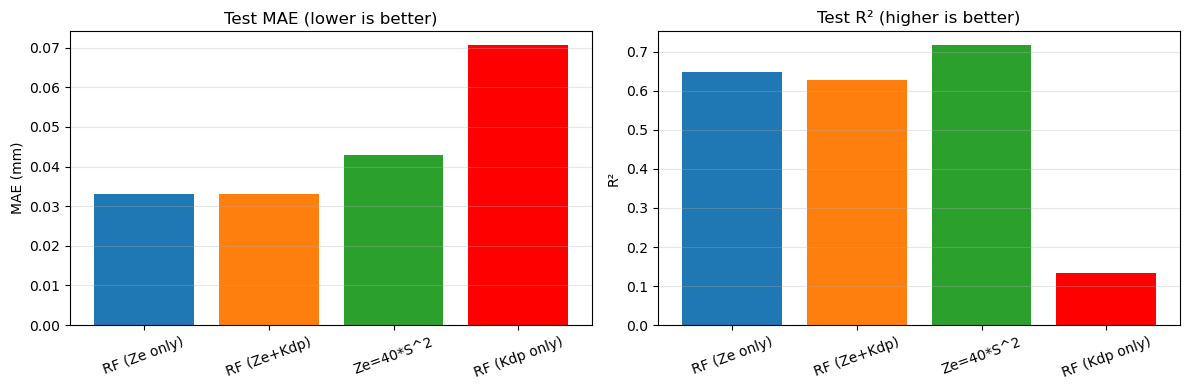

In [13]:
# Side-by-side bar chart of the test metrics:
#   left panel  -> MAE (lower is better)
#   right panel -> R²  (higher is better)
bar_colors = ['tab:blue', 'tab:orange', 'tab:green', 'red']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cmp_test['model'], cmp_test['MAE_mm'], color=bar_colors)
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('Test MAE (lower is better)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(cmp_test['model'], cmp_test['R2'], color=bar_colors)
axes[1].set_ylabel('R²')
axes[1].set_title('Test R² (higher is better)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

As you can see from above, using reflectivity only gives the best performance. This is consistent with the findings of @Jackson_2026_SQUIRE when they evaluated empirical $Z_{e}-S$ and $K_{dp}-S$ relationships against Pluvio^2 snow water equivalents. @Jackson_2026_SQUIRE concluded that this could be explained by the relatively dry nature of the snow observed during SAIL that would not exhibit significant values of $K_{dp}$. Therefore, this provides us with even more confidence that the Random Forest provides a robust estimate of snow water equivalent.



## 5. (Optional) Neural Network comparison

For perspective, we train a small **multi-layer perceptron (MLP)** with the same three feature setups
(`Ze`, `Kdp`, `Ze + Kdp`). Two things to notice:

- The MLP needs its inputs **scaled** (`StandardScaler`) — unlike the RF, which ignores scale entirely.
- We use `early_stopping=True` so training stops automatically once the internal validation score plateaus.

This isn't a fair fight (no architecture search, no extensive tuning), but it's a useful sanity check:
the MLP and RF should land in a similar neighbourhood, and the **physical baseline should remain competitive**.

Feel free to use this as a launchpad for experimentation:
- Tune the RF (`n_estimators`, `max_depth`, `max_features`, …)
- Tune the MLP (`hidden_layer_sizes`, `alpha`, `learning_rate_init`, …)
- Try gradient-boosted trees (`HistGradientBoostingRegressor`) — often the strongest tabular model.

In [14]:
# Factory for a small MLP wrapped in a Pipeline that first standard-scales the inputs.
# Pipeline ensures the scaler is fit on training data and reused at predict-time
# (no leakage of validation/test statistics into preprocessing).
def make_nn():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('nn', MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),  # three hidden layers, narrowing toward the output
            activation='relu',
            solver='adam',
            alpha=1e-4,                        # L2 weight decay (regularisation)
            learning_rate_init=1e-3,
            early_stopping=True,               # stop when a 15% internal val split stops improving
            validation_fraction=0.15,
            n_iter_no_change=20,               # patience for early stopping
            max_iter=800,
            random_state=42,
        )),
    ])

In [15]:
# Build three fresh MLPs, one per feature setup.
nn_ze   = make_nn()
nn_kdp  = make_nn()
nn_both = make_nn()

# Train the Ze-only MLP. (Set verbose=True on the inner estimator if you want
# to see per-iteration loss / validation scores.)
print('Training NN (Ze only)...')
nn_ze.fit(Xtr_ze, y_train)
print(f"  done. iterations: {nn_ze.named_steps['nn'].n_iter_}, final loss: {nn_ze.named_steps['nn'].loss_:.6f}")

Training NN (Ze only)...
  done. iterations: 114, final loss: 0.016806


In [16]:
# Train the Kdp-only MLP.
print('Training NN (Kdp only)...')
nn_kdp.fit(Xtr_kdp, y_train)
print(f"  done. iterations: {nn_kdp.named_steps['nn'].n_iter_}, final loss: {nn_kdp.named_steps['nn'].loss_:.6f}")

Training NN (Kdp only)...
  done. iterations: 37, final loss: 0.020916


In [17]:
# Train the Ze + Kdp MLP (full 82-feature input).
print('Training NN (Ze + Kdp)...')
nn_both.fit(Xtr_both, y_train)
print(f"  done. iterations: {nn_both.named_steps['nn'].n_iter_}, final loss: {nn_both.named_steps['nn'].loss_:.6f}")

Training NN (Ze + Kdp)...
  done. iterations: 77, final loss: 0.016522


In [18]:
# Predictions from each MLP on validation and test.
y_nn_ze_val   = nn_ze.predict(Xva_ze)
y_nn_kdp_val  = nn_kdp.predict(Xva_kdp)
y_nn_both_val = nn_both.predict(Xva_both)

y_nn_ze   = nn_ze.predict(Xte_ze)
y_nn_kdp  = nn_kdp.predict(Xte_kdp)
y_nn_both = nn_both.predict(Xte_both)

# Reuse the baseline values we already computed for the RF section.
y_ze_rel_val = y_ze_val
y_ze_rel     = y_ze_test

# Comparison table on the test split.
cmp_nn = pd.DataFrame([
    score('NN (Ze+Kdp)',  y_test, y_nn_both),
    score('NN (Ze only)', y_test, y_nn_ze),
    score('NN (Kdp only)', y_test, y_nn_kdp),
    score('Ze=40*S^2',    y_test, y_ze_rel),
]).sort_values('MAE_mm').reset_index(drop=True)

print('Test metrics (held-out days):')
print(cmp_nn.to_string(index=False))
print(f"\nBest test by MAE: {cmp_nn.loc[0, 'model']}")

Test metrics (held-out days):
        model   MAE_mm       R2
 NN (Ze only) 0.034453 0.754924
  NN (Ze+Kdp) 0.035973 0.480501
    Ze=40*S^2 0.042969 0.716526
NN (Kdp only) 0.068628 0.050628

Best test by MAE: NN (Ze only)


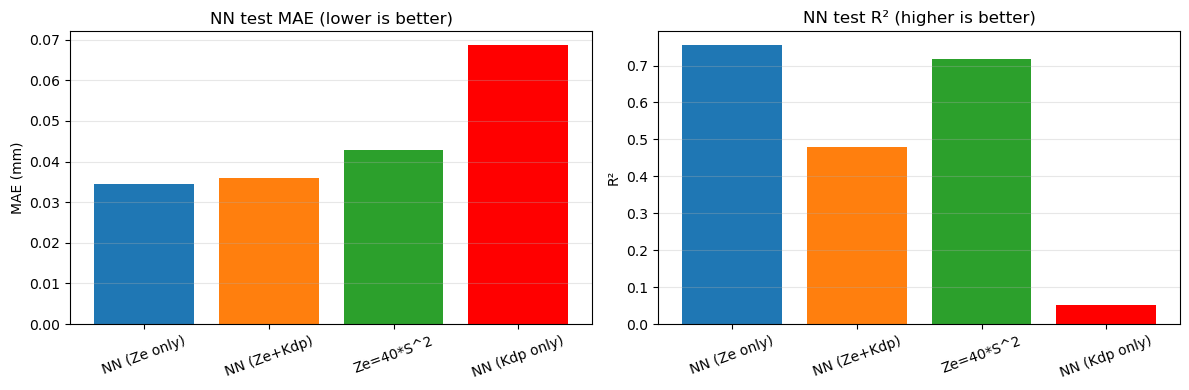

In [19]:
# Same MAE / R² bar layout as the RF section, this time for the MLP family.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cmp_nn['model'], cmp_nn['MAE_mm'], color=bar_colors)
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('NN test MAE (lower is better)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(cmp_nn['model'], cmp_nn['R2'], color=bar_colors)
axes[1].set_ylabel('R²')
axes[1].set_title('NN test R² (higher is better)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

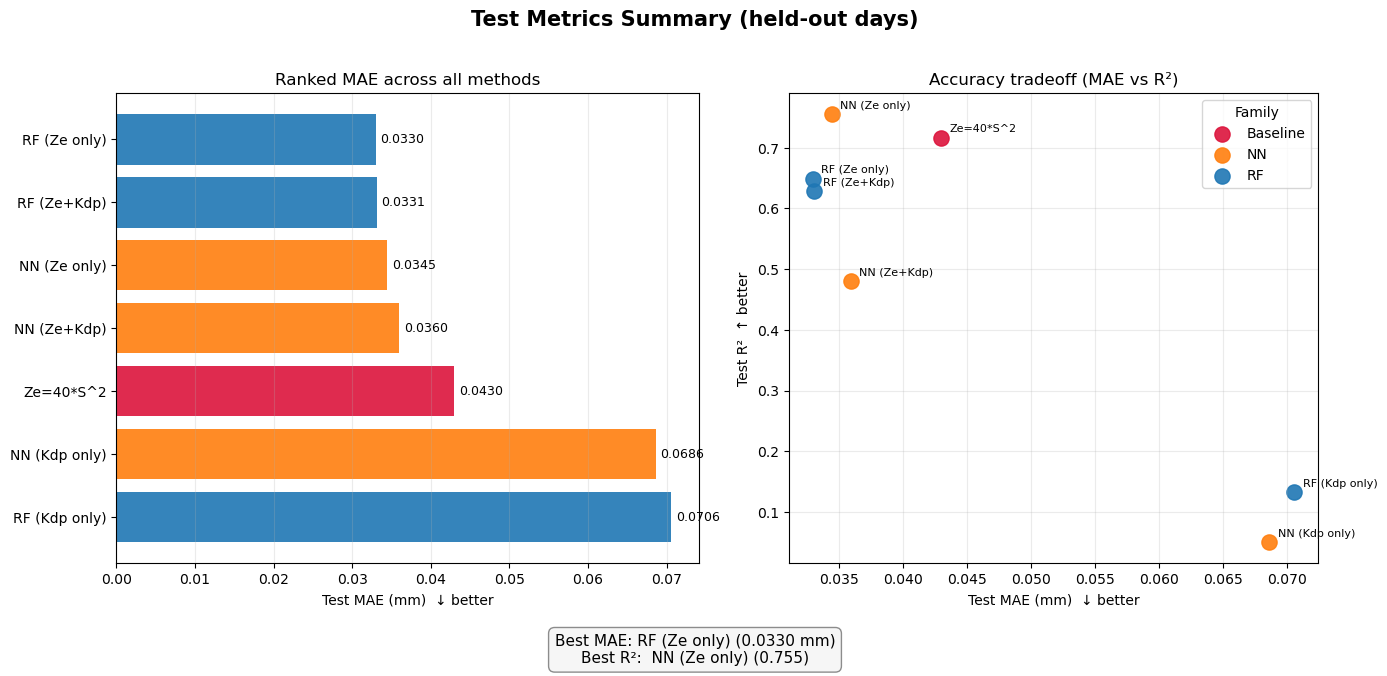

Best MAE: RF (Ze only) (0.0330 mm)
Best R²:  NN (Ze only) (0.755)


In [20]:
# Side-by-side, slide-ready summary of every method we trained.
#   Panel A: ranked horizontal bars of test MAE (best at top).
#   Panel B: scatter of MAE vs R², coloured by model family.

# Combine RF rows, NN rows, and a single baseline row into one table.
rf_rows       = cmp_test[cmp_test['model'].str.contains('RF')].copy()
baseline_rows = cmp_test[cmp_test['model'].str.contains('Ze=')].copy()
nn_rows       = cmp_nn[cmp_nn['model'].str.contains('NN')].copy()
results = pd.concat([rf_rows, nn_rows, baseline_rows], ignore_index=True)
results['family'] = np.where(
    results['model'].str.contains('RF'), 'RF',
    np.where(results['model'].str.contains('NN'), 'NN', 'Baseline'),
)

best_mae = results.loc[results['MAE_mm'].idxmin()]
best_r2  = results.loc[results['R2'].idxmax()]

family_color = {'RF': 'tab:blue', 'NN': 'tab:orange', 'Baseline': 'crimson'}
ranked = results.sort_values('MAE_mm', ascending=True).reset_index(drop=True)
bar_colors_ranked = [family_color[f] for f in ranked['family']]

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.0])

# Panel A: ranked MAE bars (best at top).
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(ranked['model'], ranked['MAE_mm'], color=bar_colors_ranked, alpha=0.9)
ax1.invert_yaxis()
ax1.set_xlabel('Test MAE (mm)  ↓ better')
ax1.set_title('Ranked MAE across all methods')
ax1.grid(axis='x', alpha=0.25)
for i, v in enumerate(ranked['MAE_mm']):
    ax1.text(v + 0.0006, i, f'{v:.4f}', va='center', fontsize=9)

# Panel B: MAE vs R² tradeoff.
ax2 = fig.add_subplot(gs[0, 1])
for fam, grp in results.groupby('family'):
    ax2.scatter(grp['MAE_mm'], grp['R2'], s=120, alpha=0.9,
                label=fam, color=family_color[fam])
    for _, r in grp.iterrows():
        ax2.annotate(r['model'], (r['MAE_mm'], r['R2']),
                     xytext=(6, 4), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Test MAE (mm)  ↓ better')
ax2.set_ylabel('Test R²  ↑ better')
ax2.set_title('Accuracy tradeoff (MAE vs R²)')
ax2.grid(alpha=0.25)
ax2.legend(title='Family', frameon=True)

summary = (
    f"Best MAE: {best_mae['model']} ({best_mae['MAE_mm']:.4f} mm)\n"
    f"Best R²:  {best_r2['model']} ({best_r2['R2']:.3f})"
)
fig.text(0.5, -0.02, summary, ha='center', va='top', fontsize=11,
         bbox=dict(boxstyle='round,pad=0.4', fc='whitesmoke', ec='gray', alpha=0.9))

fig.suptitle('Test Metrics Summary (held-out days)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(summary)

## 6. Wrap-up & where to go next

What this notebook showed:

- A **Random Forest** trained on simple radar profile features can match — and sometimes beat — a textbook
  `Ze = 40 · S²` baseline, with no feature scaling and very little tuning.
- **Ze contributes most of the signal** in this dataset: the $Z_{e}$-only RF is essentially as good as the
  $Z_{e} + K_{dp}$ RF, while the $K_{dp}$-only RF lags well behind. That's a useful, defensible feature-importance result.
- A small **MLP** lands in the same ballpark as the RF, but the **physical baseline is hard to dethrone**
  — a good reminder that "ML beats physics" is *not* the default outcome on a well-posed problem.
- After all, @Jackson_2026_SQUIRE found that the physical baselines based on $Z_{e}$-only had the best agreement with the
  Pluvio weighing bucket raingauge and melted snow equivalent measurements during SAIL. 
  
- So the lesson to learn here is that just because something has AI in it does not mean that it's better than the old school methods. But this is always worth exploring, especially since MPL and Random Forests are relatively light weight and easy to train.

Suggested next experiments:

1. **Inspect feature importance** — `rf_both.feature_importances_` is a 1D array of length 82. Plot it vs
   height to see *which heights* the forest leans on most.
2. **Tune the RF** — try `max_depth`, `max_features='sqrt'`, or `HistGradientBoostingRegressor` for a
   typically-stronger boosted-tree alternative.
3. **Add features** — combine Ze and Kdp profiles with derived quantities (e.g. column-mean Ze, gradient of
   Ze with height) and see if they help.
4. **Cross-validate by case/storm**, not just by day, for a more robust estimate of generalisation error.

---
:::{important}**Exercise for the Students**
Use the recommended $Z_{e}-S$ and $K_{dp}-S$ relationships from @Jackson_2026_SQUIRE to calibrate the physical baseline and determine if the RF or MLP models can still beat (or match) these physical relationships.
:::